In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [27]:
df = pd.read_csv("data_test.csv", sep=";")
df.sample(10)


,CLIENT_ID,VALUE_DAY,DIGITAL_30_CNT,TRAN_ACTIVE_30_CNT,OPER_ACTIVE_30_CNT
621786,1019635127,31.01.2022,8.0,2.0,2.0
748820,4203431115,28.02.2022,17.0,8.0,8.0
53510,74363464,30.09.2021,11.0,5.0,5.0
239559,3291328984,31.10.2021,7.0,1.0,2.0
411224,3881709304,31.12.2021,10.0,1.0,2.0
700877,4044880173,28.02.2022,6.0,1.0,1.0
800515,3550030281,28.02.2022,1.0,1.0,1.0
633732,460216945,31.01.2022,NaN,NaN,NaN
757374,1087915539,28.02.2022,16.0,0.0,1.0
79334,3865943116,30.09.2021,13.0,8.0,8.0


In [28]:
print(df['DIGITAL_30_CNT'].isna().mean())
print(df['OPER_ACTIVE_30_CNT'].isna().mean())
print(df['TRAN_ACTIVE_30_CNT'].isna().mean())


0.11746032927908308
0.11746032927908308
0.11746032927908308


In [29]:
df.info()
print(df.DIGITAL_30_CNT.isna().sum())
print(df.TRAN_ACTIVE_30_CNT.isna().sum())
print(df.OPER_ACTIVE_30_CNT.isna().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 805821 entries, 0 to 805820
Data columns (total 5 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   CLIENT_ID           805821 non-null  int64  
 1   VALUE_DAY           805821 non-null  object 
 2   DIGITAL_30_CNT      711169 non-null  float64
 3   TRAN_ACTIVE_30_CNT  711169 non-null  float64
 4   OPER_ACTIVE_30_CNT  711169 non-null  float64
dtypes: float64(3), int64(1), object(1)
memory usage: 30.7+ MB
94652
94652
94652


Увидел, что NAN составляет 11%. Сделаю предположение, что там НЕТ ДАННЫХ, а не нулевая активность


In [30]:
cols = ["DIGITAL_30_CNT", "TRAN_ACTIVE_30_CNT", "OPER_ACTIVE_30_CNT"]

df = df.dropna(subset=cols, how="all")


In [40]:
print(df['DIGITAL_30_CNT'].isna().mean())
print(df['OPER_ACTIVE_30_CNT'].isna().mean())
print(df['TRAN_ACTIVE_30_CNT'].isna().mean())


0.0
0.0
0.0


In [31]:
df["VALUE_DAY"] = pd.to_datetime(df["VALUE_DAY"], format="%d.%m.%Y")


Построй визуальное представление удержания клиентов в статусе:
- активных клиентов банка (наличие строки для клиента на отчетную дату); 
- диджитал активных (активных в мобильном приложении: наличие хотя бы одного входа);
- операционно активных;
- транзакционно активных;


In [32]:
# для каждого задания бинарные признаки

df["is_active"] = 1 #клиент вообще жив

df["is_digital"] = (df["DIGITAL_30_CNT"] > 0).astype(int) #клиент заходит в приложение

df["is_oper"] = (df["OPER_ACTIVE_30_CNT"] > 0).astype(int) #какие-то мутки мутит

df["is_tran"] = (df["TRAN_ACTIVE_30_CNT"] > 0).astype(int) #клиент приносит деньги


In [33]:

first_month = df.groupby("CLIENT_ID")["VALUE_DAY"].min().reset_index()
first_month.columns = ["CLIENT_ID", "cohort_month"]

df = df.merge(first_month, on="CLIENT_ID")

# номер мес от когорты

df["cohort_index"] = (
    (df["VALUE_DAY"].dt.year - df["cohort_month"].dt.year) * 12 +
    (df["VALUE_DAY"].dt.month - df["cohort_month"].dt.month)

)


In [34]:
# расчет retention
def get_retention(df, flag):

    cohort = (
        df.groupby(["cohort_month", "cohort_index"])
        .agg({flag: "sum", "CLIENT_ID": "nunique"})
        .rename(columns={"CLIENT_ID": "total_users"})
        .reset_index())

    cohort_pivot = cohort.pivot(
        index="cohort_month",
        columns="cohort_index",
        values=flag)

    cohort_size = cohort_pivot.iloc[:, 0]

    retention = cohort_pivot.divide(cohort_size, axis=0) #делим каждую строку на первый столбец
    return retention


In [35]:
# считаем retention

ret_active = get_retention(df, "is_active")
ret_digital = get_retention(df, "is_digital")
ret_oper = get_retention(df, "is_oper")
ret_tran = get_retention(df, "is_tran")


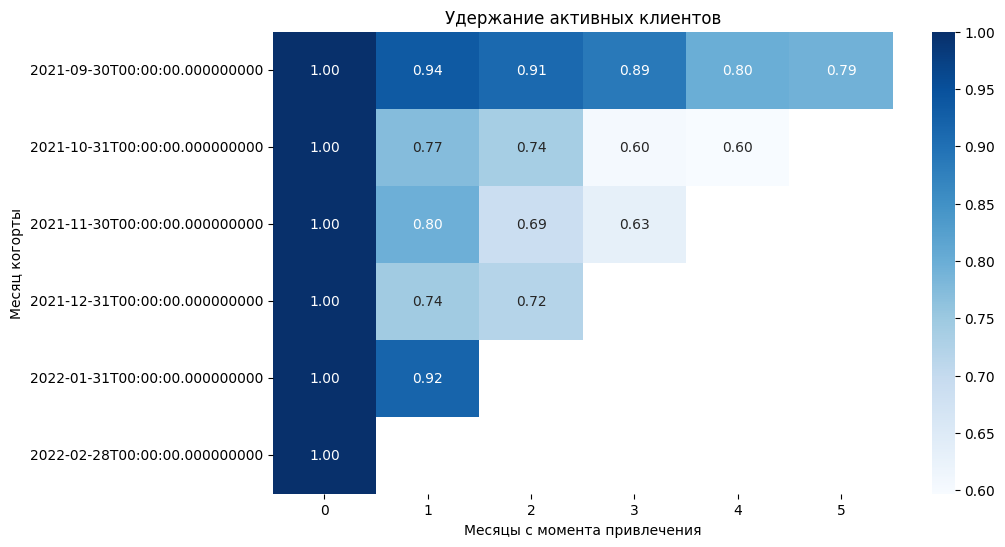

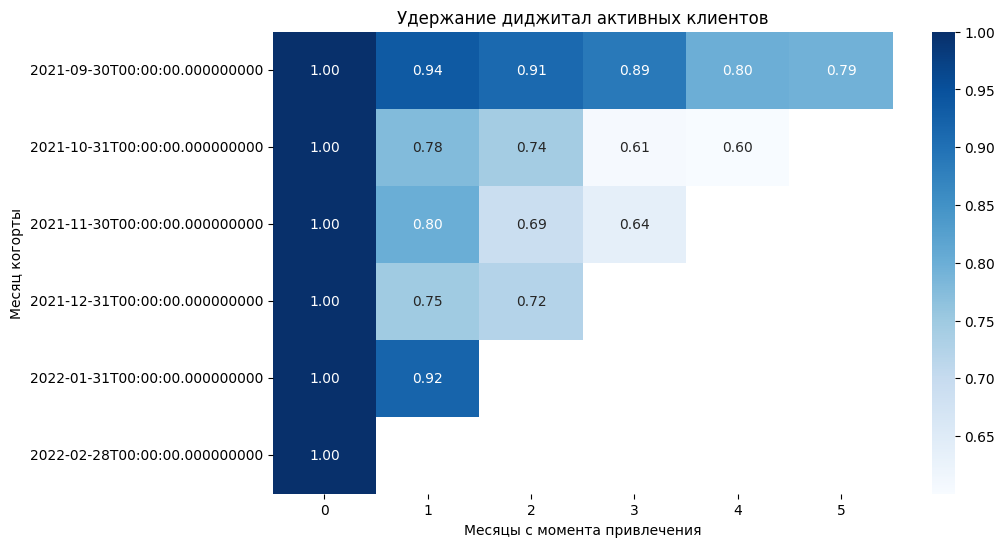

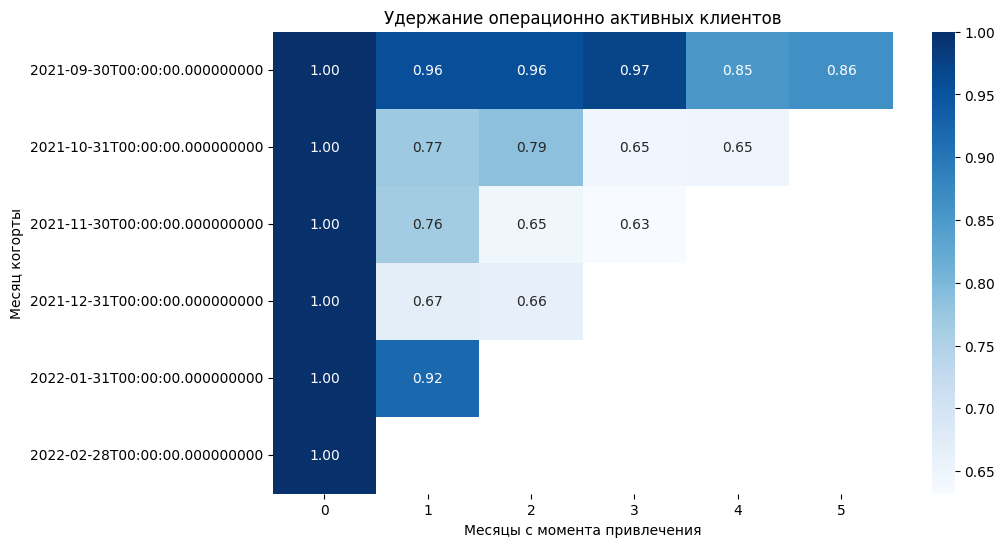

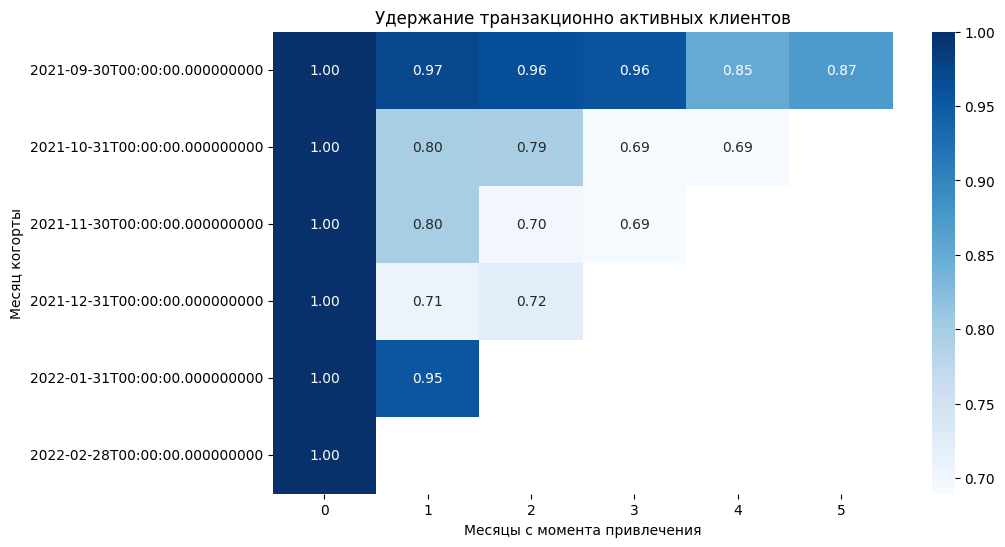

In [36]:
def plot_heatmap(retention, title):
    plt.figure(figsize=(10,6))
    sns.heatmap(retention, annot=True, fmt=".2f", cmap="Blues")
    plt.title(title)
    plt.xlabel("Месяцы с момента привлечения")
    plt.ylabel("Месяц когорты")
    plt.show()

plot_heatmap(ret_active, "Удержание активных клиентов")
plot_heatmap(ret_digital, "Удержание диджитал активных клиентов")
plot_heatmap(ret_oper, "Удержание операционно активных клиентов")
plot_heatmap(ret_tran, "Удержание транзакционно активных клиентов")


In [37]:
df["tran_in_digital"] = np.where(df["is_digital"] == 1,
                                df["is_tran"],
                                np.nan)

penetration = df.groupby("VALUE_DAY")["tran_in_digital"].mean()
print(penetration)


VALUE_DAY
2021-09-30    0.691066
2021-10-31    0.704560
2021-11-30    0.712475
2021-12-31    0.722945
2022-01-31    0.716281
2022-02-28    0.737392
Name: tran_in_digital, dtype: float64


69–73% digital-пользователей совершают транзакции

Проверка частота входов

In [38]:
df.groupby("is_oper")["DIGITAL_30_CNT"].mean()


is_oper
0     4.199510
1    13.598693
Name: DIGITAL_30_CNT, dtype: float64

In [42]:
print(13.5/4.199)


3.215051202667302


в 3 раза операционные пользаки чаще заходят

<Axes: xlabel='is_oper', ylabel='DIGITAL_30_CNT'>

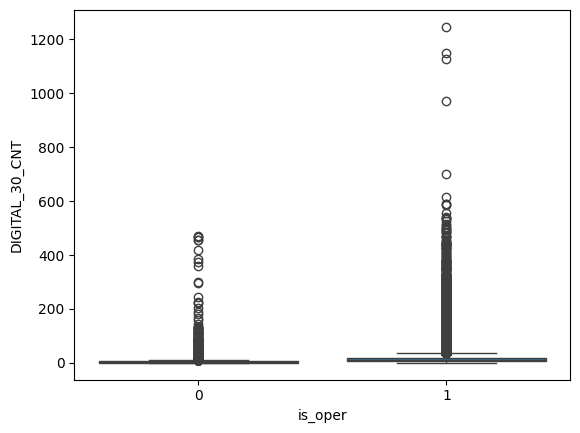

In [43]:
import seaborn as sns

sns.boxplot(x="is_oper", y="DIGITAL_30_CNT", data=df)


In [44]:
from scipy.stats import ttest_ind

a = df[df["is_oper"] == 0]["DIGITAL_30_CNT"]
b = df[df["is_oper"] == 1]["DIGITAL_30_CNT"]

ttest_ind(a, b, equal_var=False)

TtestResult(statistic=np.float64(-341.3802825106504), pvalue=np.float64(0.0), df=np.float64(656979.049073428))

In [ ]:
mean_0 = a.mean()

mean_1 = b.mean()

std_0 = a.std()

std_1 = b.std()

cohen_d = (mean_1 - mean_0) / np.sqrt((std_0**2 + std_1**2)/2)

cohen_d

np.float64(0.7414490901119133)

In [48]:
std_1

np.float64(16.82583706161555)

разница стат значима (0,74)


чем чаще пользователь заходит, тем выше шанс, что он сделает операцию

Зашел, а зачем зашел?

In [39]:
conversion = df[df["is_digital"] == 1]["is_oper"].mean()
conversion

np.float64(0.7852017627162651)

Вывод

- Четверть пользователей заходят в приложение, но не совершают операций/транзакций!
Возможно, приложение юзают, чтобы посмотреть баланс, проверить траты. Или его не привлекают активности на экране, ему не хочется никуда больше тыкать, кроме своего целевого действия. У них нет регулярных платежей, чтобы их совершать. Но возможно, кому-то просто удобнее делать это не в приложении, а в вебе, где крупнее.

- Ключевым фактором является вовлеченность, ибо юзеры, совершающие операции, заходят в приложение в среднем в 3 раза чаще и снова предполагаем, что часть юзеров использует приложение в пассивном режиме 

- Полагаю, что для проверки гипотез необходимо провести сегментацию пользователей, анализ частоты входов и построение воронки 

Если получится увеличить вовлеченность, то основной точкой роста вижу увеличение конверсии из диджитал активности в операционную. Вероятно, в этом поможет упрощение пользовательских сценариев и внедрения мотивационных механик (или геймификации в UI).

